# Rolex Watch Price Analysis - Part 1: Data Preparation
## Final Project - Data Analytics

## Libraries and settings

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## 1. Data Collection

The data was collected using web scraping from Chrono24.com, one of the world's largest marketplaces for luxury watches. Chrono24 connects private sellers and professional dealers globally, offering a comprehensive view of the Rolex watch market.

The scraping process captured:
- Watch specifications (model, reference number, materials)
- Pricing information
- Condition and documentation details
- Seller information
- Geographic location data

## 2. Import Raw Data

In [2]:
df_raw = pd.read_csv('chrono.csv', encoding='utf-8')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:2d}. {col}")

Dataset shape: (577, 19)

Column names:
 1. web_scraper_order
 2. web_scraper_start_url
 3. watch
 4. watch-href
 5. name_raw
 6. listing_code_raw
 7. brand_raw
 8. reference_number_raw
 9. model_raw
10. movement_raw
11. condition_raw
12. scope_of_delivery_raw
13. seller_type
14. case_material
15. production_year
16. location_raw
17. price_raw
18. bracelet_material
19. description


In [3]:
df_raw.head(10)

,web_scraper_order,web_scraper_start_url,watch,watch-href,name_raw,listing_code_raw,brand_raw,reference_number_raw,model_raw,movement_raw,condition_raw,scope_of_delivery_raw,seller_type,case_material,production_year,location_raw,price_raw,bracelet_material,description
0,1766756167-1,https://www.chrono24.com/rolex/index-10.htm,Rolex Submariner Date\n \n\n \n ...,https://www.chrono24.com/rolex/submariner-date...,Popular,NUKBA4,Rolex,126613lb,Submariner Date,Automatic,Used (Incomplete)\n \n ...,"Original box, original papers",Professional dealer,Gold/Steel,2020,"United States of America, NEW YORK","CHF14,532",Gold/Steel,The Rolex Submariner Date reference 126613LB w...
1,1766756169-2,https://www.chrono24.com/rolex/index-10.htm,Rolex GMT-Master II\n \n\n \n ...,https://www.chrono24.com/rolex/like-new-gmt-ma...,NaN,Q68E72,Rolex,116713,GMT-Master II,Automatic,Used (Very good)\n \n ...,"Original box, no original papers",Partner Certified Included,Gold/Steel,Unknown,"United States of America, California, Los Angeles","CHF10,895",Gold/Steel,"This watch is used but in MINT condition, read..."
2,1766756171-3,https://www.chrono24.com/rolex/index-10.htm,Rolex GMT-Master II\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-new-2025-...,NaN,PVT190,Rolex,126711CHNR,GMT-Master II,Automatic,New\n \n ...,"Original box, original papers",Professional dealer,Gold/Steel,2025,"United States of America, Michigan, Oak Park, MI","CHF18,314",Gold/Steel,"NEW 2025 Rolex GMT-Master II ""Rootbeer"" 40mm T..."
3,1766756173-4,https://www.chrono24.com/rolex/index-10.htm,Rolex Yacht-Master II\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-yacht-mas...,NaN,MEDFZ4,Rolex,116680,Yacht-Master II,Automatic,Like new & unworn\n \n ...,"Original box, original papers",Professional dealer,Steel,2021,"United States of America, Florida, Miami","CHF15,218",Steel,Rolex Yacht Master II Mercedes Hands\n\n\nRefe...
4,1766756175-5,https://www.chrono24.com/rolex/index-10.htm,Rolex Datejust 41\n \n\n \n ...,https://www.chrono24.com/rolex/new-2025-unworn...,Popular\n\nPopular\n\nPopular\n\nPopular\n\nPo...,PZ22A1,Rolex,126334,Datejust 41,Automatic,New\n \n ...,"Original box, original papers",Professional dealer,Steel,2025,"United States of America, California, Los Angeles","CHF11,299",Steel,"This watch is brand new, unworn, ready to ship..."
5,1766756177-6,https://www.chrono24.com/rolex/index-10.htm,Rolex Datejust 36\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-126234-da...,Popular\n\nPopular,OOL2U3,Rolex,126234,Datejust 36,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Professional dealer,Steel,2021,"United States of America, Florida, Orlando","CHF11,767",Steel,Condition: Very Good\n\n\nWarranty Dated: Marc...
6,1766756179-7,https://www.chrono24.com/rolex/index-10.htm,Rolex Lady-Datejust\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-lady-date...,NaN,PVTAS4,Rolex,279383RBR,Lady-Datejust,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Professional dealer,Gold/Steel,2020,"United States of America, California, Newport ...","CHF21,390",Gold/Steel,This beautiful Rolex is IN STOCK and ready to ...
7,1766756182-8,https://www.chrono24.com/rolex/index-10.htm,Rolex Datejust 36\n \n\n \n ...,https://www.chrono24.com/rolex/rolex-16233-dat...,NaN,KOZGM8,Rolex,16233,Datejust 36,Automatic,Used (Very good)\n \n ...,"Original box, original papers",Partner Certified Included,Gold/Steel,1990,"United States of America, New York, NEW YORK","CHF6,136",Gold/Steel,16233\n\n\nRolex Datejust 36 Men's or Women's ...
8,1766756184-9,https://www.chrono24.com/rolex/index-10.htm,Rolex Datejust 36\n \n\n \n ...,https://www.chrono24.com/rolex/new-2025-unworn...,Popular,PHPZC1,Rolex,126200\n \n ...,Datejust 36,Automatic,New\n \n ...,"Original box, original papers",Professional dealer,Steel,2025,"United States of America, California, Los Angeles","CHF8,877",Steel,"This watch is brand new, unworn, ready to ship..."
9,1766756186-10,https://www.chrono24.com/rolex/in

## 3. Initial Data Exploration

In [4]:
print("Data types:")
print(df_raw.dtypes)
print("\n" + "="*60)
print("\nMissing values:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

Data types:
web_scraper_order        object
web_scraper_start_url    object
watch                    object
watch-href               object
name_raw                 object
listing_code_raw         object
brand_raw                object
reference_number_raw     object
model_raw                object
movement_raw             object
condition_raw            object
scope_of_delivery_raw    object
seller_type              object
case_material            object
production_year          object
location_raw             object
price_raw                object
bracelet_material        object
description              object
dtype: object


Missing values:
                      Missing  Percentage
name_raw                  223       38.65
description                26        4.51
case_material               2        0.35
reference_number_raw        1        0.17
model_raw                   1        0.17
movement_raw                1        0.17


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      577 non-null    object
 1   web_scraper_start_url  577 non-null    object
 2   watch                  577 non-null    object
 3   watch-href             577 non-null    object
 4   name_raw               354 non-null    object
 5   listing_code_raw       577 non-null    object
 6   brand_raw              577 non-null    object
 7   reference_number_raw   576 non-null    object
 8   model_raw              576 non-null    object
 9   movement_raw           576 non-null    object
 10  condition_raw          577 non-null    object
 11  scope_of_delivery_raw  577 non-null    object
 12  seller_type            577 non-null    object
 13  case_material          575 non-null    object
 14  production_year        577 non-null    object
 15  location_raw           

In [6]:
print("Sample of raw price values:")
print(df_raw['price_raw'].head(20))

Sample of raw price values:
0     CHF14,532
1     CHF10,895
2     CHF18,314
3     CHF15,218
4     CHF11,299
5     CHF11,767
6     CHF21,390
7      CHF6,136
8      CHF8,877
9     CHF15,783
10    CHF14,350
11    CHF11,283
12    CHF12,106
13     CHF3,940
14    CHF11,262
15    CHF15,823
16    CHF31,079
17    CHF14,270
18    CHF18,968
19    CHF39,152
Name: price_raw, dtype: object


## 4. Data Cleaning and Feature Engineering

### 4.1 Extract Numeric Price from price_raw

In [7]:
def extract_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    numbers = re.findall(r'[\d,]+', price_str)
    if numbers:
        price = numbers[0].replace(',', '')
        try:
            return float(price)
        except:
            return np.nan
    return np.nan

df_raw['price'] = df_raw['price_raw'].apply(extract_price)

print(f"Price extraction results:")
print(f"  Successfully extracted: {df_raw['price'].notna().sum():,} prices")
print(f"  Failed to extract: {df_raw['price'].isna().sum():,} prices")
print(f"\nPrice statistics:")
print(f"  Minimum: {df_raw['price'].min():,.2f} CHF")
print(f"  Maximum: {df_raw['price'].max():,.2f} CHF")
print(f"  Mean: {df_raw['price'].mean():,.2f} CHF")
print(f"  Median: {df_raw['price'].median():,.2f} CHF")

Price extraction results:
  Successfully extracted: 572 prices
  Failed to extract: 5 prices

Price statistics:
  Minimum: 3,068.00 CHF
  Maximum: 101,722.00 CHF
  Mean: 19,141.81 CHF
  Median: 14,124.00 CHF


### 4.2 Extract Production Year

In [8]:
def extract_year(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str)
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', year_str)
    if years:
        year = int(years[0])
        if 1900 <= year <= 2024:
            return year
    return np.nan

df_raw['year'] = df_raw['production_year'].apply(extract_year)

print(f"Year extraction results:")
print(f"  Successfully extracted: {df_raw['year'].notna().sum():,} years")
print(f"  Failed to extract: {df_raw['year'].isna().sum():,} years")
print(f"\nYear statistics:")
print(f"  Earliest: {df_raw['year'].min():.0f}")
print(f"  Latest: {df_raw['year'].max():.0f}")
print(f"  Mean: {df_raw['year'].mean():.0f}")
print(f"  Median: {df_raw['year'].median():.0f}")

Year extraction results:
  Successfully extracted: 390 years
  Failed to extract: 187 years

Year statistics:
  Earliest: 1962
  Latest: 2024
  Mean: 2016
  Median: 2020


### 4.3 Calculate Watch Age

In [9]:
current_year = 2024
df_raw['age'] = current_year - df_raw['year']
df_raw['age'] = df_raw['age'].apply(lambda x: x if pd.notna(x) and 0 <= x <= 100 else np.nan)

print(f"Age statistics:")
print(f"  Minimum age: {df_raw['age'].min():.0f} years")
print(f"  Maximum age: {df_raw['age'].max():.0f} years")
print(f"  Average age: {df_raw['age'].mean():.1f} years")
print(f"  Median age: {df_raw['age'].median():.0f} years")

Age statistics:
  Minimum age: 0 years
  Maximum age: 62 years
  Average age: 8.5 years
  Median age: 4 years


### 4.4 Categorize Watch Condition

In [10]:
def categorize_condition(condition_str):
    if pd.isna(condition_str):
        return 'Unknown'
    condition_str = str(condition_str).lower()
    if 'new' in condition_str or 'unworn' in condition_str:
        return 'New'
    elif 'very good' in condition_str:
        return 'Very Good'
    elif 'good' in condition_str:
        return 'Good'
    elif 'fair' in condition_str:
        return 'Fair'
    elif 'incomplete' in condition_str or 'not functional' in condition_str:
        return 'Incomplete'
    else:
        return 'Used'

df_raw['condition_category'] = df_raw['condition_raw'].apply(categorize_condition)

print("Condition distribution:")
print(df_raw['condition_category'].value_counts())
print(f"\nPercentage distribution:")
print((df_raw['condition_category'].value_counts() / len(df_raw) * 100).round(2))

Condition distribution:
condition_category
Very Good     292
New           248
Good           36
Incomplete      1
Name: count, dtype: int64

Percentage distribution:
condition_category
Very Good     50.61
New           42.98
Good           6.24
Incomplete     0.17
Name: count, dtype: float64


### 4.5 Extract Geographic Information

In [11]:
def extract_country(location_str):
    if pd.isna(location_str):
        return 'Unknown'
    location_str = str(location_str).strip()
    parts = location_str.split(',')
    if len(parts) >= 1:
        return parts[0].strip()
    return 'Unknown'

def extract_city(location_str):
    if pd.isna(location_str):
        return 'Unknown'
    location_str = str(location_str).strip()
    parts = location_str.split(',')
    if len(parts) >= 2:
        return parts[1].strip()
    return 'Unknown'

df_raw['country'] = df_raw['location_raw'].apply(extract_country)
df_raw['city'] = df_raw['location_raw'].apply(extract_city)

print("Top 15 countries:")
print(df_raw['country'].value_counts().head(15))
print(f"\nTotal unique countries: {df_raw['country'].nunique()}")

Top 15 countries:
country
United States of America    577
Name: count, dtype: int64

Total unique countries: 1


### 4.6 Create Binary Features for Documentation

In [12]:
df_raw['has_box'] = df_raw['scope_of_delivery_raw'].fillna('').str.lower().str.contains('box').astype(int)
df_raw['has_papers'] = df_raw['scope_of_delivery_raw'].fillna('').str.lower().str.contains('paper').astype(int)
df_raw['has_complete_set'] = ((df_raw['has_box'] == 1) & (df_raw['has_papers'] == 1)).astype(int)

print(f"Documentation statistics:")
print(f"  Watches with box: {df_raw['has_box'].sum():,} ({df_raw['has_box'].mean()*100:.1f}%)")
print(f"  Watches with papers: {df_raw['has_papers'].sum():,} ({df_raw['has_papers'].mean()*100:.1f}%)")
print(f"  Watches with complete set: {df_raw['has_complete_set'].sum():,} ({df_raw['has_complete_set'].mean()*100:.1f}%)")

Documentation statistics:
  Watches with box: 577 (100.0%)
  Watches with papers: 577 (100.0%)
  Watches with complete set: 577 (100.0%)


### 4.7 Create Seller Type Binary Variable

In [24]:
df_raw['is_professional'] = (df_raw['seller_type'] == 'Professional dealer').astype(int)

print("Seller type distribution:")
print(df_raw['seller_type'].value_counts())
print(f"\nProfessional dealers: {df_raw['is_professional'].sum():,} ({df_raw['is_professional'].mean()*100:.1f}%)")

Seller type distribution:
seller_type
Professional dealer           457
Partner Certified Included    105
Private Seller                 15
Name: count, dtype: int64

Professional dealers: 457 (79.2%)


### 4.8 Extract and Clean Material Information

In [14]:
def clean_material(material_str):
    if pd.isna(material_str):
        return 'Unknown'
    material_str = str(material_str).strip()
    if material_str == '':
        return 'Unknown'
    return material_str

df_raw['case_material_clean'] = df_raw['case_material'].apply(clean_material)
df_raw['bracelet_material_clean'] = df_raw['bracelet_material'].apply(clean_material)

print("Top 10 case materials:")
print(df_raw['case_material_clean'].value_counts().head(10))
print("\nTop 10 bracelet materials:")
print(df_raw['bracelet_material_clean'].value_counts().head(10))

Top 10 case materials:
case_material_clean
Steel          343
Gold/Steel     115
Yellow gold     43
Rose gold       30
White gold      25
Platinum        14
Titanium         4
Unknown          2
Silver           1
Name: count, dtype: int64

Top 10 bracelet materials:
bracelet_material_clean
Steel           343
Gold/Steel      123
Yellow gold      32
Rubber           22
Rose gold        18
White gold       15
Platinum         14
Leather           5
Titanium          4
Ostrich skin      1
Name: count, dtype: int64


### 4.9 Create Material Category Features

In [15]:
def categorize_material(material_str):
    if pd.isna(material_str):
        return 'Unknown'
    material_str = str(material_str).lower()
    
    if 'gold' in material_str and 'steel' in material_str:
        return 'Gold/Steel'
    elif 'yellow gold' in material_str or 'gold (solid)' in material_str:
        return 'Yellow Gold'
    elif 'white gold' in material_str:
        return 'White Gold'
    elif 'rose gold' in material_str or 'pink gold' in material_str:
        return 'Rose Gold'
    elif 'platinum' in material_str:
        return 'Platinum'
    elif 'steel' in material_str:
        return 'Steel'
    else:
        return 'Other'

df_raw['material_category'] = df_raw['case_material_clean'].apply(categorize_material)

print("Material category distribution:")
print(df_raw['material_category'].value_counts())

Material category distribution:
material_category
Steel          343
Gold/Steel     115
Yellow Gold     43
Rose Gold       30
White Gold      25
Platinum        14
Other            7
Name: count, dtype: int64


### 4.10 Extract Movement Type

In [16]:
def categorize_movement(movement_str):
    if pd.isna(movement_str):
        return 'Unknown'
    movement_str = str(movement_str).lower()
    
    if 'automatic' in movement_str:
        return 'Automatic'
    elif 'manual' in movement_str or 'hand' in movement_str:
        return 'Manual'
    elif 'quartz' in movement_str:
        return 'Quartz'
    else:
        return 'Unknown'

df_raw['movement_type'] = df_raw['movement_raw'].apply(categorize_movement)

print("Movement type distribution:")
print(df_raw['movement_type'].value_counts())

Movement type distribution:
movement_type
Automatic    573
Manual         2
Quartz         1
Unknown        1
Name: count, dtype: int64


## 5. Select Final Columns and Clean Dataset

In [17]:
columns_final = [
    'web_scraper_order',
    'brand_raw',
    'model_raw',
    'reference_number_raw',
    'movement_type',
    'condition_category',
    'seller_type',
    'case_material_clean',
    'bracelet_material_clean',
    'material_category',
    'country',
    'city',
    'price',
    'year',
    'age',
    'has_box',
    'has_papers',
    'has_complete_set',
    'is_professional'
]

df_clean = df_raw[columns_final].copy()

print(f"Dataset after column selection: {df_clean.shape}")

Dataset after column selection: (577, 19)


### Remove records with missing price

In [18]:
print(f"Records before removing missing prices: {len(df_clean):,}")
df_clean = df_clean.dropna(subset=['price'])
print(f"Records after removing missing prices: {len(df_clean):,}")
print(f"Records removed: {len(df_raw) - len(df_clean):,}")

Records before removing missing prices: 577
Records after removing missing prices: 572
Records removed: 5


### Filter price outliers

In [19]:
print(f"Records before filtering outliers: {len(df_clean):,}")
df_clean = df_clean[(df_clean['price'] >= 1000) & (df_clean['price'] <= 500000)]
print(f"Records after filtering outliers: {len(df_clean):,}")
print(f"\nPrice range after filtering:")
print(f"  Minimum: {df_clean['price'].min():,.2f} CHF")
print(f"  Maximum: {df_clean['price'].max():,.2f} CHF")
print(f"  Mean: {df_clean['price'].mean():,.2f} CHF")
print(f"  Median: {df_clean['price'].median():,.2f} CHF")

Records before filtering outliers: 572
Records after filtering outliers: 572

Price range after filtering:
  Minimum: 3,068.00 CHF
  Maximum: 101,722.00 CHF
  Mean: 19,141.81 CHF
  Median: 14,124.00 CHF


### Remove duplicates

In [20]:
print(f"Records before removing duplicates: {len(df_clean):,}")
df_clean = df_clean.drop_duplicates()
print(f"Records after removing duplicates: {len(df_clean):,}")

Records before removing duplicates: 572
Records after removing duplicates: 572


## 6. Final Dataset Summary

In [21]:
print("="*70)
print("FINAL DATASET SUMMARY")
print("="*70)
print(f"\nDataset shape: {df_clean.shape}")
print(f"  - {df_clean.shape[0]:,} records")
print(f"  - {df_clean.shape[1]} features")
print(f"\nMissing values in final dataset:")
missing_final = df_clean.isnull().sum()
missing_pct_final = (missing_final / len(df_clean) * 100).round(2)
missing_df_final = pd.DataFrame({
    'Missing': missing_final,
    'Percentage': missing_pct_final
})
print(missing_df_final[missing_df_final['Missing'] > 0].sort_values('Missing', ascending=False))

FINAL DATASET SUMMARY

Dataset shape: (572, 19)
  - 572 records
  - 19 features

Missing values in final dataset:
                      Missing  Percentage
year                      184       32.17
age                       184       32.17
model_raw                   1        0.17
reference_number_raw        1        0.17


In [26]:
df_clean.head(10)

,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766756167-1,Rolex,Submariner Date,126613lb,Automatic,Incomplete,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,NEW YORK,14532.0,2020.0,4.0,1,1,1,1
1,1766756169-2,Rolex,GMT-Master II,116713,Automatic,Very Good,Partner Certified Included,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,California,10895.0,NaN,NaN,1,1,1,0
2,1766756171-3,Rolex,GMT-Master II,126711CHNR,Automatic,New,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,Michigan,18314.0,NaN,NaN,1,1,1,1
3,1766756173-4,Rolex,Yacht-Master II,116680,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,Florida,15218.0,2021.0,3.0,1,1,1,1
4,1766756175-5,Rolex,Datejust 41,126334,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,California,11299.0,NaN,NaN,1,1,1,1
5,1766756177-6,Rolex,Datejust 36,126234,Automatic,Very Good,Professional dealer,Steel,Steel,Steel,United States of America,Florida,11767.0,2021.0,3.0,1,1,1,1
6,1766756179-7,Rolex,Lady-Datejust,279383RBR,Automatic,Very Good,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,California,21390.0,2020.0,4.0,1,1,1,1
7,1766756182-8,Rolex,Datejust 36,16233,Automatic,Very Good,Partner Certified Included,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,New York,6136.0,1990.0,34.0,1,1,1,0
8,1766756184-9,Rolex,Datejust 36,126200\n \n ...,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,California,8877.0,NaN,NaN,1,1,1,1
9,1766756186-10,Rolex,Datejust 41,126333,Automatic,New,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,New Jersey,15783.0,NaN,NaN,1,1,1,1


In [27]:
df_clean.describe()

,price,year,age,has_box,has_papers,has_complete_set,is_professional
count,572.000000,388.000000,388.000000,572.0,572.0,572.0,572.000000
mean,19141.807692,2015.487113,8.512887,1.0,1.0,1.0,0.790210
std,15844.542691,11.734899,11.734899,0.0,0.0,0.0,0.407515
min,3068.000000,1962.000000,0.000000,1.0,1.0,1.0,0.000000
25%,10415.000000,2015.000000,1.000000,1.0,1.0,1.0,1.000000
50%,14124.000000,2020.000000,4.000000,1.0,1.0,1.0,1.000000
75%,20087.000000,2023.000000,9.000000,1.0,1.0,1.0,1.000000
max,101722.000000,2024.000000,62.000000,1.0,1.0,1.0,1.000000


In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 572 entries, 0 to 576
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   web_scraper_order        572 non-null    object 
 1   brand_raw                572 non-null    object 
 2   model_raw                571 non-null    object 
 3   reference_number_raw     571 non-null    object 
 4   movement_type            572 non-null    object 
 5   condition_category       572 non-null    object 
 6   seller_type              572 non-null    object 
 7   case_material_clean      572 non-null    object 
 8   bracelet_material_clean  572 non-null    object 
 9   material_category        572 non-null    object 
 10  country                  572 non-null    object 
 11  city                     572 non-null    object 
 12  price                    572 non-null    float64
 13  year                     388 non-null    float64
 14  age                      388 no

## 7. Save Cleaned Dataset

In [29]:
output_file = 'rolex_data_cleaned.csv'
df_clean.to_csv(output_file, index=False, encoding='utf-8')
print(f"Cleaned dataset saved to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1024 / 1024:.2f} MB")

Cleaned dataset saved to: rolex_data_cleaned.csv
File size: 0.10 MB


## 8. Quick Visualization of Key Variables

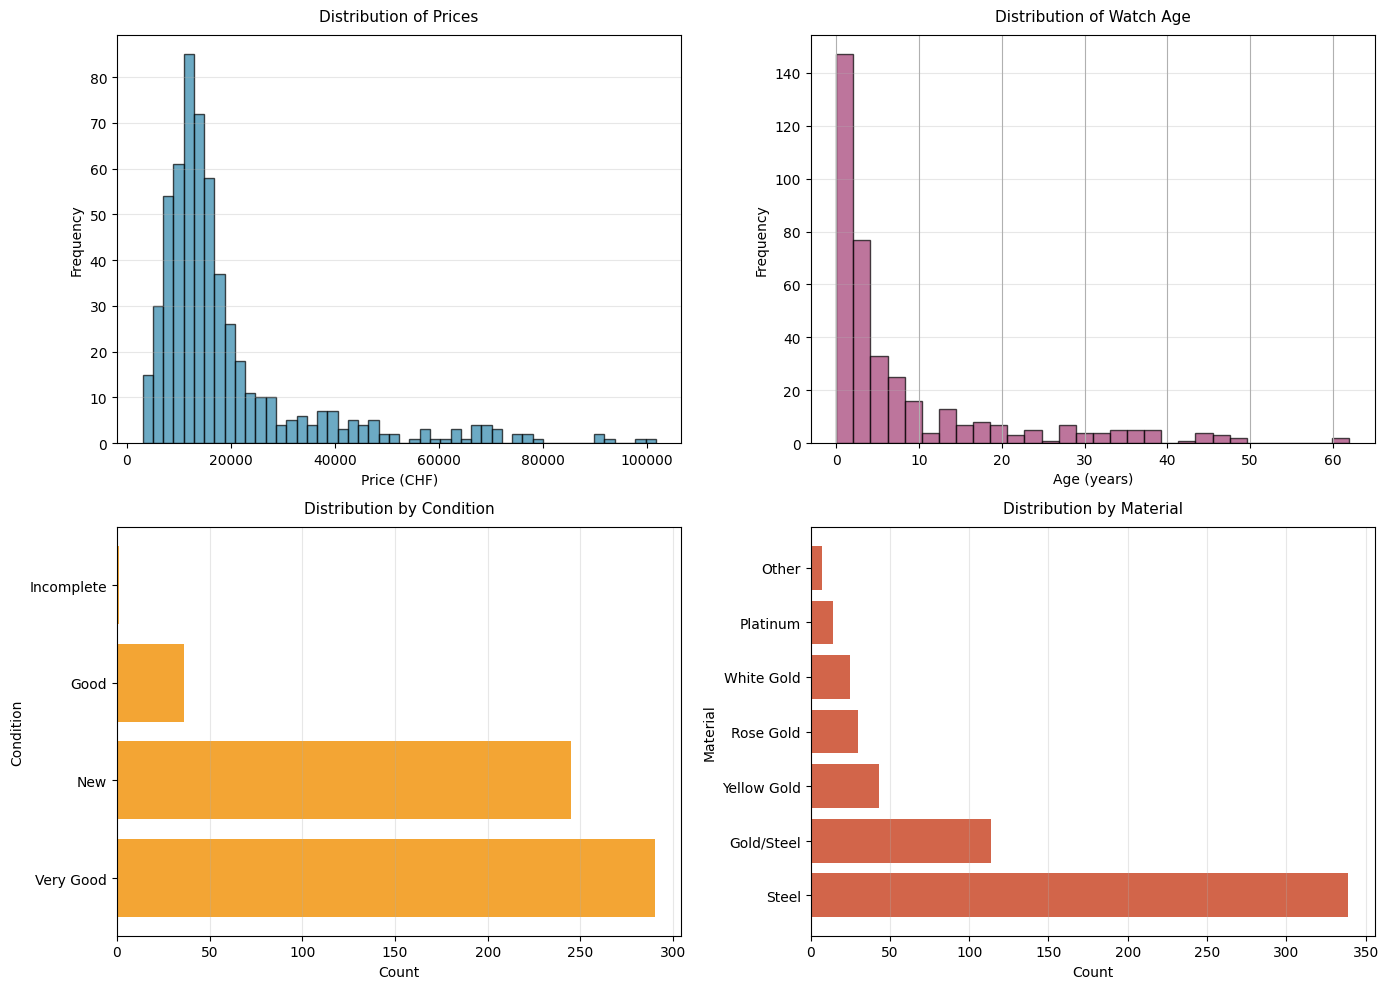

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_clean['price'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price (CHF)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Distribution of Prices', fontsize=11, pad=10)
axes[0, 0].grid(axis='y', alpha=0.3)

df_clean['age'].dropna().hist(bins=30, ax=axes[0, 1], color='#A23B72', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age (years)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Distribution of Watch Age', fontsize=11, pad=10)
axes[0, 1].grid(axis='y', alpha=0.3)

condition_counts = df_clean['condition_category'].value_counts()
axes[1, 0].barh(condition_counts.index, condition_counts.values, color='#F18F01', alpha=0.8)
axes[1, 0].set_xlabel('Count', fontsize=10)
axes[1, 0].set_ylabel('Condition', fontsize=10)
axes[1, 0].set_title('Distribution by Condition', fontsize=11, pad=10)
axes[1, 0].grid(axis='x', alpha=0.3)

material_counts = df_clean['material_category'].value_counts()
axes[1, 1].barh(material_counts.index, material_counts.values, color='#C73E1D', alpha=0.8)
axes[1, 1].set_xlabel('Count', fontsize=10)
axes[1, 1].set_ylabel('Material', fontsize=10)
axes[1, 1].set_title('Distribution by Material', fontsize=11, pad=10)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [31]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.2.0
Datetime: 2025-12-26 19:41:33
Python Version: 3.11.13
-----------------------------------
